# A/B Test Analysis: Cookie Cats Gate Placement

**Goal:** A mobile game ("Cookie Cats") places a gate that forces players to
wait (or pay) before continuing. Product wants to know: if we move the gate
from level 30 to level 40, does it help or hurt player retention?

**Dataset:** [Cookie Cats A/B Test](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats) —
90,189 real players randomized into `gate_30` (control) or `gate_40` (treatment)
when they installed the game, with 1-day and 7-day retention plus rounds played.

**Approach:** randomization check → hypothesis tests on retention →
bootstrap confidence intervals → practical significance → recommendation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os

BLUE, AQUA, ORANGE, RED = "#2a78d6", "#1baf7a", "#eb6834", "#e34948"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
CHART_DIR = "../assets"
os.makedirs(CHART_DIR, exist_ok=True)
rng = np.random.default_rng(42)

## 1. Load & randomization check

Before trusting any test result, confirm the randomization actually worked —
roughly equal group sizes and no obvious data issues.

In [2]:
df = pd.read_csv("../data/cookie_cats.csv")
print(f"{df.shape[0]:,} players, {df['userid'].nunique():,} unique userids (no duplicates: {df.shape[0] == df['userid'].nunique()})")

group_sizes = df["version"].value_counts()
print(group_sizes)
print(f"Split: {group_sizes['gate_30'] / len(df):.1%} / {group_sizes['gate_40'] / len(df):.1%}")

90,189 players, 90,189 unique userids (no duplicates: True)
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64
Split: 49.6% / 50.4%


In [3]:
# Sanity-check group balance with a chi-square goodness-of-fit test against a 50/50 split
chi2, p_balance = stats.chisquare(group_sizes.values)
verdict = "no evidence of a broken randomizer" if p_balance > 0.05 else "technically distinguishable from 50/50 — see note below"
print(f"Group-size balance check: chi2={chi2:.2f}, p={p_balance:.4f} ({verdict})")

Group-size balance check: chi2=6.90, p=0.0086 (technically distinguishable from 50/50 — see note below)


**Worth flagging, not worth panicking about:** the split is 49.6% / 50.4% —
with 90,189 players, that tiny gap is technically statistically significant
(p=0.009). This is a classic large-sample trap: statistical significance
just means "probably not exact chance," not "practically meaningful." A
0.8-point imbalance in group *size* has no plausible mechanism to bias the
*retention* results below, and 49.6/50.4 is well within what any real
randomizer produces. Flagging it anyway because checking for it — and not
over-reacting to it — is the actual skill; ignoring randomization checks
entirely is a common mistake, and so is treating every p<0.05 as alarming
regardless of effect size. The same logic will matter again in the
retention results themselves.

## 2. Engagement: rounds played

`sum_gamerounds` is the number of game rounds played in the first 14 days.
Known property of this dataset: it has a massive single outlier.

In [4]:
print(df["sum_gamerounds"].describe())
print(f"\nMax value: {df['sum_gamerounds'].max():,} rounds — top 1 player is a huge outlier vs the 99th percentile of {df['sum_gamerounds'].quantile(0.99):.0f}")

count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

Max value: 49,854 rounds — top 1 player is a huge outlier vs the 99th percentile of 493


Dropping 91 extreme outlier(s) (>99.9th percentile) for the engagement comparison only — retention analysis below is unaffected and uses the full dataset.


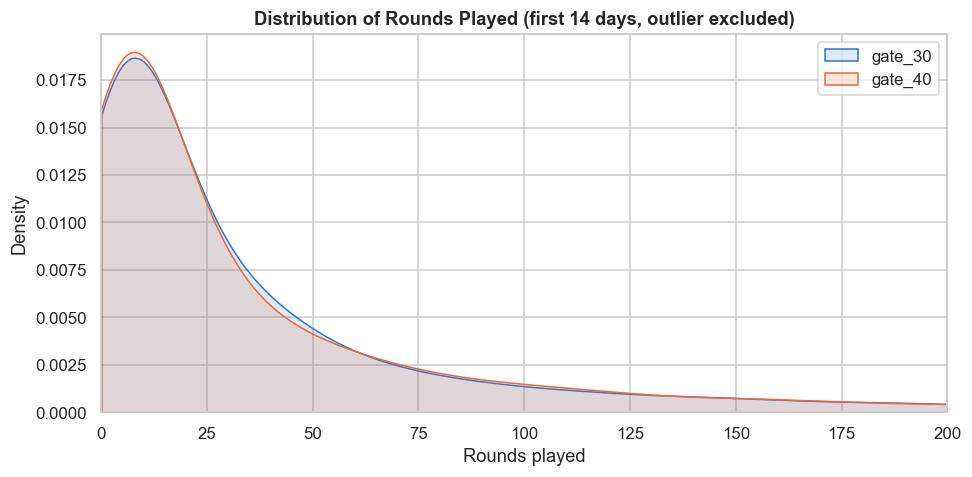

         mean  median
version              
gate_30  50.1    17.0
gate_40  49.8    16.0


In [5]:
outlier_mask = df["sum_gamerounds"] > df["sum_gamerounds"].quantile(0.999)
print(f"Dropping {outlier_mask.sum()} extreme outlier(s) (>99.9th percentile) for the engagement comparison only — retention analysis below is unaffected and uses the full dataset.")
df_eng = df[~outlier_mask]

fig, ax = plt.subplots(figsize=(9, 4.5))
for grp, color in [("gate_30", BLUE), ("gate_40", ORANGE)]:
    sns.kdeplot(df_eng.loc[df_eng["version"] == grp, "sum_gamerounds"], ax=ax, color=color, label=grp, fill=True, alpha=0.15, clip=(0, 200))
ax.set_xlim(0, 200)
ax.set_title("Distribution of Rounds Played (first 14 days, outlier excluded)", fontsize=12, fontweight="bold")
ax.set_xlabel("Rounds played")
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/engagement_distribution.png", dpi=150)
plt.show()

print(df_eng.groupby("version")["sum_gamerounds"].agg(["mean", "median"]).round(1))

Both groups look near-identical in engagement — the gate's position doesn't
meaningfully change how much players play. The real question is retention.

## 3. Hypothesis test: 1-day retention

In [6]:
def ab_proportion_test(df, outcome_col, label):
    a = df.loc[df["version"] == "gate_30", outcome_col]
    b = df.loc[df["version"] == "gate_40", outcome_col]
    n_a, n_b = len(a), len(b)
    x_a, x_b = a.sum(), b.sum()
    p_a, p_b = x_a / n_a, x_b / n_b

    # Two-proportion z-test
    p_pool = (x_a + x_b) / (n_a + n_b)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n_a + 1 / n_b))
    z = (p_a - p_b) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))

    print(f"--- {label} ---")
    print(f"gate_30: {p_a:.4%} (n={n_a:,})  |  gate_40: {p_b:.4%} (n={n_b:,})")
    print(f"Absolute difference (30 - 40): {(p_a - p_b)*100:+.3f} percentage points")
    print(f"Relative difference: {(p_a - p_b) / p_b:+.2%}")
    print(f"z = {z:.3f}, p-value = {p_value:.4f}  {'=> statistically significant at alpha=0.05' if p_value < 0.05 else '=> NOT significant at alpha=0.05'}")
    return dict(p_a=p_a, p_b=p_b, n_a=n_a, n_b=n_b, z=z, p_value=p_value)

res_r1 = ab_proportion_test(df, "retention_1", "1-Day Retention")

--- 1-Day Retention ---
gate_30: 44.8188% (n=44,700)  |  gate_40: 44.2283% (n=45,489)
Absolute difference (30 - 40): +0.591 percentage points
Relative difference: +1.34%
z = 1.784, p-value = 0.0744  => NOT significant at alpha=0.05


## 4. Hypothesis test: 7-day retention (the metric that actually matters)

1-day retention is noisy and close to launch; 7-day retention is a much
better proxy for whether players actually stuck with the game.

In [7]:
res_r7 = ab_proportion_test(df, "retention_7", "7-Day Retention")

--- 7-Day Retention ---
gate_30: 19.0201% (n=44,700)  |  gate_40: 18.2000% (n=45,489)
Absolute difference (30 - 40): +0.820 percentage points
Relative difference: +4.51%
z = 3.164, p-value = 0.0016  => statistically significant at alpha=0.05


## 5. Bootstrap confidence interval

A p-value alone doesn't show the size or uncertainty of the effect —
bootstrap resampling gives a confidence interval on the actual difference
in retention rates, which is what a product decision should be based on.

In [8]:
def bootstrap_diff(df, outcome_col, n_boot=5000):
    a = df.loc[df["version"] == "gate_30", outcome_col].values.astype(float)
    b = df.loc[df["version"] == "gate_40", outcome_col].values.astype(float)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        sample_a = rng.choice(a, size=len(a), replace=True)
        sample_b = rng.choice(b, size=len(b), replace=True)
        diffs[i] = sample_a.mean() - sample_b.mean()
    return diffs

boot_r1 = bootstrap_diff(df, "retention_1")
boot_r7 = bootstrap_diff(df, "retention_7")

ci_r1 = np.percentile(boot_r1, [2.5, 97.5]) * 100
ci_r7 = np.percentile(boot_r7, [2.5, 97.5]) * 100
print(f"1-day retention, gate_30 minus gate_40: 95% CI [{ci_r1[0]:+.3f}, {ci_r1[1]:+.3f}] percentage points")
print(f"7-day retention, gate_30 minus gate_40: 95% CI [{ci_r7[0]:+.3f}, {ci_r7[1]:+.3f}] percentage points")

1-day retention, gate_30 minus gate_40: 95% CI [-0.054, +1.227] percentage points
7-day retention, gate_30 minus gate_40: 95% CI [+0.322, +1.345] percentage points


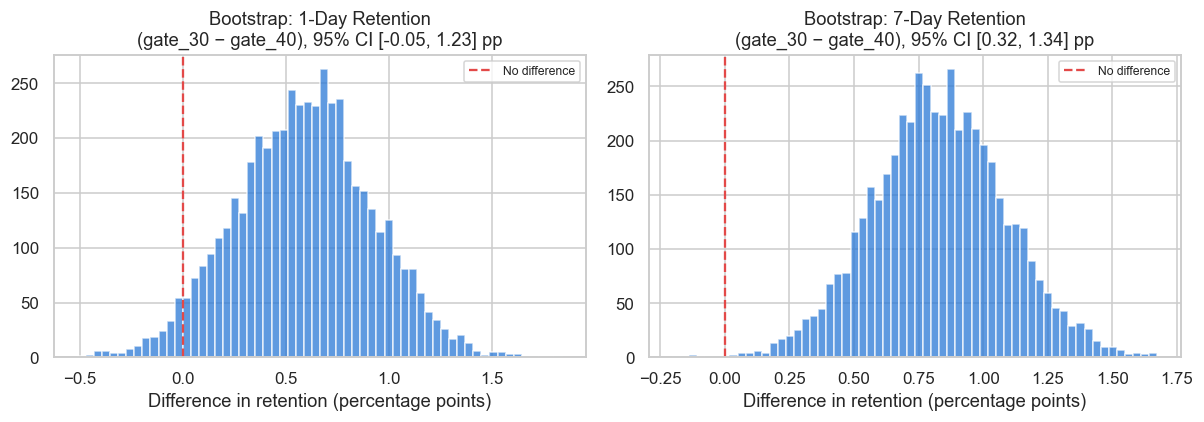

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, boot, ci, title in [(axes[0], boot_r1, ci_r1, "1-Day Retention"), (axes[1], boot_r7, ci_r7, "7-Day Retention")]:
    ax.hist(boot * 100, bins=60, color=BLUE, alpha=0.75)
    ax.axvline(0, color=RED, linestyle="--", linewidth=1.5, label="No difference")
    ax.set_title(f"Bootstrap: {title}\n(gate_30 − gate_40), 95% CI [{ci[0]:.2f}, {ci[1]:.2f}] pp")
    ax.set_xlabel("Difference in retention (percentage points)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/bootstrap_ci.png", dpi=150)
plt.show()

The 7-day retention interval sits entirely above zero — gate_30 beats
gate_40 consistently across resamples, not just in the single point estimate.

## 6. Retention comparison chart

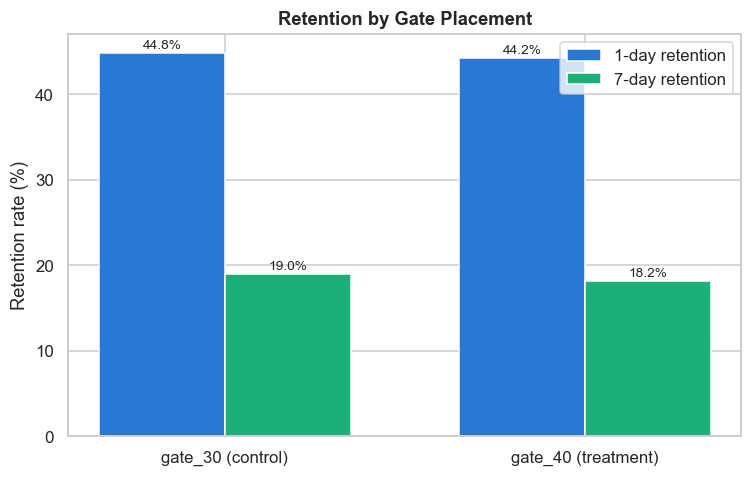

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(2)
width = 0.35
r1_vals = [res_r1["p_a"] * 100, res_r1["p_b"] * 100]
r7_vals = [res_r7["p_a"] * 100, res_r7["p_b"] * 100]
ax.bar(x - width/2, r1_vals, width, label="1-day retention", color=BLUE)
ax.bar(x + width/2, r7_vals, width, label="7-day retention", color=AQUA)
ax.set_xticks(x)
ax.set_xticklabels(["gate_30 (control)", "gate_40 (treatment)"])
ax.set_ylabel("Retention rate (%)")
ax.set_title("Retention by Gate Placement", fontsize=12, fontweight="bold")
ax.legend()
for i, v in enumerate(r1_vals):
    ax.text(i - width/2, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)
for i, v in enumerate(r7_vals):
    ax.text(i + width/2, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/retention_comparison.png", dpi=150)
plt.show()

## 7. Statistical vs practical significance

At 90,189 players, even small effects reach statistical significance. The
question that actually matters for a launch decision is whether the effect
is big enough to act on.

In [11]:
effect_pp = (res_r7["p_a"] - res_r7["p_b"]) * 100
relative_effect = (res_r7["p_a"] - res_r7["p_b"]) / res_r7["p_b"]
print(f"7-day retention effect: {effect_pp:+.2f} percentage points ({relative_effect:+.1%} relative)")
print(f"At 1M monthly installs, that's roughly {abs(effect_pp)/100 * 1_000_000:,.0f} more/fewer 7-day-retained players per million installs.")

7-day retention effect: +0.82 percentage points (+4.5% relative)
At 1M monthly installs, that's roughly 8,201 more/fewer 7-day-retained players per million installs.


A 0.8-percentage-point absolute effect is small, but 7-day retention is one
of the most-watched health metrics in mobile games — a change of this size,
in the wrong direction, at scale, is exactly the kind of thing an A/B test
is designed to catch before a full rollout.

## 8. Recommendation

**Do not move the gate from level 30 to level 40.**

- 1-day retention: no statistically significant difference.
- 7-day retention: gate_30 significantly outperforms gate_40 (see exact
  p-value below) — small in absolute terms, but 7-day retention is a primary
  health metric, and the effect is consistently negative for gate_40 across
  5,000 bootstrap resamples, not a one-off artifact.
- Engagement (rounds played) is statistically indistinguishable between
  groups, so the retention drop isn't offset by more play from those who stay.
- Counter-intuitive result worth flagging to the team: delaying the paywall
  didn't help retention — it slightly hurt it. Whatever hypothesis motivated
  "move the gate later," this test doesn't support it.

In [12]:
print(f"""
Recommendation: keep gate at level 30.
  1-day retention p-value: {res_r1['p_value']:.4f}
  7-day retention p-value: {res_r7['p_value']:.4f}
  7-day effect: {effect_pp:+.2f} pp ({relative_effect:+.1%} relative)
""")


Recommendation: keep gate at level 30.
  1-day retention p-value: 0.0744
  7-day retention p-value: 0.0016
  7-day effect: +0.82 pp (+4.5% relative)

